## 1.- REGRESION LINEAL SIMPLE


EL DATASET QUE USARE ES UN DATASET QUE HACE REFERENCIA A MI TRABAJO EN MARTINREA

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [165]:
#USAMOS LA LIBRERIA PANDAS PD PARA LEER EL DATASET ENVIADO
df = pd.read_csv("PRDUCTION_MARTINREA_DATASET.csv")

df

,DATE,PIECES_OK,PIECES_SCRAP,TOTAL_PIECES,CODE_ERROR,MACHINE,CURRENT_MODEL
0,2026-02-24,444,183,261,reventado,ART_ENDFORM_1861,TE0939
1,2026-02-20,538,84,454,reventado,ART_ENDFORM_1861,TE0952
2,2026-02-24,459,186,273,reventado,ART_ENDFORM_1861,TE0939
3,2026-02-20,558,32,526,arruga,ART_ENDFORM_1859,TE0939
4,2026-02-25,403,47,356,arruga,ART_ENDFORM_1859,TE0940
...,...,...,...,...,...,...,...
239,2026-02-25,415,70,345,reventado,ART_ENDFORM_1861,TE0940
240,2026-02-25,561,101,460,reventado,ART_ENDFORM_1861,TE0940
241,2026-02-20,522,101,421,arruga,ART_ENDFORM_1859,TE0939
242,2026-02-25,429,173,256,reventado,ART_ENDFORM_1861,TE0939


QUIERO SACAR CUANTAS PIEZAS DE SCRAP HAY DEPENDIENDO EL TOTAL DE PIEZAS POR DIA

In [166]:
#SELECCIONAR VARIABLES DE LA TABLA
x = "TOTAL_PIECES"

y = "PIECES_SCRAP"

In [167]:
#GENERAR ANALISIS
modelo = LinearRegression()
modelo.fit(df[[x]], df[y])
print('Ecuacion de la recta y = ', round(modelo.coef_[0],3), 'x + ', round(modelo.intercept_,3))

Ecuacion de la recta y =  -0.458 x +  284.572


In [168]:
#COEFICIENTE DE CORRELACION
print('Coeficientes de correlacion:', round(np.corrcoef(df[x], df[y])[0,1],3))

Coeficientes de correlacion: -0.702


In [169]:
#COEFICIENTE DE DETERMINACION
print('coeficiente de determinacion:',round(r2_score(df[y], modelo.predict(df[[x]])), 3))

coeficiente de determinacion: 0.493


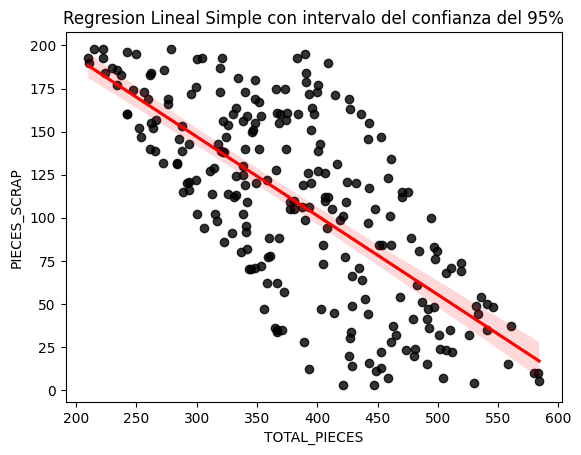

In [170]:
#GENERAR LA GRAFICA CON INTERVALOS
sns.regplot(x=df[x], y=df[y], ci=95, line_kws={"color":"red"}, scatter_kws={"color": "black"})

plt.title('Regresion Lineal Simple con intervalo del confianza del 95%')
plt.show()

COMO DATO DE PREDICCION PONDRE QUE SE PRODUJERON 400 PIEZAS AL DIA PARA PREDECIR O ESTIMAR CUANTAS PIEZAS DE SCRAP SALDRIAN

In [171]:
#GENERAR PREDICCION
dato_predictor = 400
piezas_scrap_nuevas = pd.DataFrame([dato_predictor], columns=[x])
total_produccion_prediccion = modelo.predict(piezas_scrap_nuevas)
print(f"Si se producen {dato_predictor} piezas totales, " f"se estiman {round(total_produccion_prediccion[0],3)} piezas scrap."
)

Si se producen 400 piezas totales, se estiman 101.23 piezas scrap.


## 2.- REGRESION LINEAL MULTIPLE

USARE EL MISMO DATASET, PERO AHORA TRABAJANDO CON CUANTAS PIEZAS DE SCRAP SALEN SI CADA HORA SALEN 50 PIEZAS

In [172]:
df['HOURS_WORKED'] = df['TOTAL_PIECES'] / 50

df['HOURS_WORKED']

0       5.22
1       9.08
2       5.46
3      10.52
4       7.12
       ...  
239     6.90
240     9.20
241     8.42
242     5.12
243     6.76
Name: HOURS_WORKED, Length: 244, dtype: float64

In [173]:
#DESPUES DE GENERAR HORAS TRABAJADAS

x2 = df[['TOTAL_PIECES', 'HOURS_WORKED']]
y2 = df['PIECES_SCRAP']

In [174]:
#GENERAR ANALISIS
modelo2 = LinearRegression()
modelo2.fit(x2, y2)
print('Ecuacion de la recta y = ', round(modelo2.coef_[0],3), 'x + ', round(modelo2.intercept_,3))

Ecuacion de la recta y =  -0.458 x +  284.572


In [175]:
#COEFICIENTE DE CORRELACION
print('Coeficientes de correlacion:', modelo2.coef_)

Coeficientes de correlacion: [-0.45817061 -0.00916341]


In [176]:
#COEFICIENTE DE INTERSECCION
print('coeficiente de determinacion:', modelo2.intercept_)

coeficiente de determinacion: 284.5715648404872


PREDECIR CUANTAS PIEZAS SCRAP SE ESTIMAN SI SE PRODUCEN 400 PIEZAS POR 8 HORAS

In [177]:
predicted_production = modelo2.predict([[400, 8]])
print("Piezas de scrap estimadas:", predicted_production)

Piezas de scrap estimadas: [101.23001299]


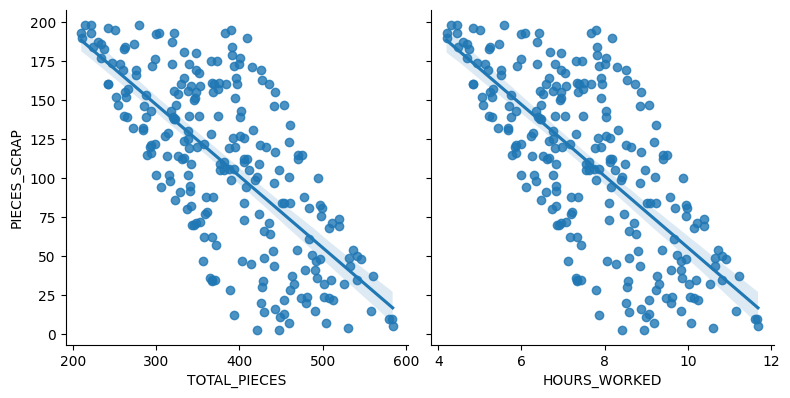

In [178]:
sns.pairplot(df, x_vars=['TOTAL_PIECES', 'HOURS_WORKED'], y_vars= 'PIECES_SCRAP', height= 4, aspect= 1, kind= 'reg')

## 3.- Bootstrapping para intervalos de confianza

ANTES DE EMPEZAR, EL BOOTSTRAPPING FUNCIONA PARA SIMULAR MUCHOS ESCENARIOS DEL MISMO DATASET PARA MEDIR INCERTIDUMBRE REAL DEL MODELO

USARE EL MISMO DATASET DEMOSTRANDO ESTA ESTRATEGIA

In [179]:
#Ocuparemos la libreria resample, para que sirve? es una herramienta fundamental utilizada para cambiar la frecuencia de los datos en series temporales, nos funcionora justo para demostrar esta estrategia
from sklearn.utils import resample

In [180]:
#Haremos predict a un estimó de 400 piezas con un intervalo de confianza del 95%
dato_predictor2 = 400

In [181]:
#Usaremos un numero de iteraciones y una variable hecha lista para guardar las predicciones
n_iterations = 1000
predictions = []

In [182]:
for i in range(n_iterations):
    df_boot = resample(df) #REMUESTREO CON RESAMPLE

    modelo_boot = LinearRegression() # ENTRENAR MODELO
    modelo_boot.fit(df_boot[[x]], df_boot[y])

    pred = modelo_boot.predict([[dato_predictor2]]) #SE GUARDA LA PREDICCION
    predictions.append(pred[0])

# INTERVALO DE CONFIANZA DEL 95%
lower = np.percentile(predictions, 2.5)
upper = np.percentile(predictions, 97.5)

print("Intervalo de confianza 95%:", round(lower,3), "-", round(upper,3))

Intervalo de confianza 95%: 96.141 - 107.424
